### Метрики качества классификации.

Сегодня мы научимся использовать различные метрики для оценки качества моделей.

Для начала загрузим данные с предыдущей домашней задачи с небольшим `сюрпризом`. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("processed_train.csv")

In [3]:
data.head()

,EngineVersion,AppVersion,AvSigVersion,RtpStateBitfield,IsSxsPassiveMode,AVProductStatesIdentifier,AVProductsInstalled,AVProductsEnabled,HasTpm,CountryIdentifier,...,Platform_windows8,Processor_x64,Processor_x86,Census_DeviceFamily_Windows.Server,Census_OSArchitecture_arm64,Census_OSArchitecture_x86,Census_GenuineStateName_IS_GENUINE,Census_GenuineStateName_OFFLINE,Census_GenuineStateName_UNKNOWN,HasDetections
0,0.552153,0.530941,0.587952,7.0,0,53447.0,1.0,1.0,1,29,...,0,1,0,0,0,0,1,0,0,0
1,0.448751,0.528931,0.484434,7.0,0,53447.0,1.0,1.0,1,93,...,0,1,0,0,0,0,0,1,0,0
2,0.552153,0.530941,0.557522,7.0,0,53447.0,1.0,1.0,1,86,...,0,1,0,0,0,0,1,0,0,0
3,0.552153,0.530941,0.482759,7.0,0,53447.0,1.0,1.0,1,97,...,0,1,0,0,0,0,1,0,0,0
4,0.493175,0.530941,0.505721,7.0,0,53447.0,1.0,1.0,1,164,...,0,1,0,0,0,0,1,0,0,0


Один из гномов очень завидовал своим братьям, переплюнувшим его по `accuracy` в бонусном задании предыдущей домашней работы. Поэтому совершил следующее злодеяние: выкинул кучу объектов таким образом, чтобы баланс классов нарушился! 

`Может, accuracy у них станет еще больше, зато преподаватель их отругает, ведь использовать accuracy при дисбалансе не очень-то хорошо!` - подумал гном

Замерьте количество объектов в порченном датафрейме.
В какой пропорции соотносятся классы теперь?

In [4]:
### Your code is here
data['HasDetections'].value_counts()




HasDetections
0    99940
1    20012
Name: count, dtype: int64

Произведем процедуру отложенной выборки:

In [5]:
y = data['HasDetections']
X = data.drop('HasDetections', axis=1)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test  = train_test_split(X, y, 
                                                     test_size=0.25, 
                                                     shuffle=True, 
                                                     random_state=1)

Обучите логистическую регрессию с параметром `l2` регуляризации `C = 0.01` на порченном датасете.
Замерьте долю верно классифицированных объектов на трейне и на тесте. Можете использовать абсолютно любые конструкции, главное не забыть пронормировать данные с помощью `StandardScaler`

In [6]:
### Your code is here
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate

pipe = Pipeline([('scaler', StandardScaler()), 
                 ('LR',LogisticRegression(C=0.01))])

pipe.fit(X_train, y_train)
print(f' accuracy на тесте {round(pipe.score(X_test,y_test), 5)}')
print(f' accuracy на трейне {round(pipe.score(X_train,y_train), 5)}')

 accuracy на тесте 0.84214
 accuracy на трейне 0.84124


In [7]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=1)
cv_results = cross_validate(pipe, X_train, y_train, 
                           cv=kf, scoring='accuracy',
                           return_train_score=True)

# Обучили на всех train данных
pipe.fit(X_train, y_train)

# Оценили на тестовых данных
test_accuracy = pipe.score(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.5f}")

Test accuracy: 0.84214


Кажется, что, по сравнению с результатами в предыдущей домашней работе, мы построили куда более сильную модель. Но мы сильно заблуждаемся, если в это верим!

**Задание 2.**
Для бинарной классификации можно построить так называемую **confision matrix** (матрица ошибок), которая подсчитывает количество правильных и неправильных предсказаний и разделяет их по двум классам:

|          | a(x) = -1  | a(x) = +1  |
|----------|------------|------------|
|  y = -1  |     TN     |     FP     |
|  y = +1  |     FN     |     TP     |

* Positive/Negative отражает то, к какому классу определила объект наша модель $a(x)$, в нашем случае нулевой класс соответствует Negative (нет вируса), а единичный класс - Positive (есть вирус).

* True/False просто показывает совпало ли предсказание модели с реальным классом объекта, поэтому на главной диагонали стоят True, а на побочной False.

**2.1)** Постройте вручную матрицу ошибок на тестовой выборке, используя реальные и предсказанные вашей моделью метки классов. Потом сравните результат с методом `confusion_matrix` в `sklearn`.

In [8]:
pred_test = pipe.predict(X_test)
pred_test

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [9]:
y_test

5433      0
117872    1
106390    1
116401    1
65995     0
         ..
115115    1
101062    1
95329     0
6052      0
58541     0
Name: HasDetections, Length: 29988, dtype: int64

In [10]:
negative = data['HasDetections'].value_counts()[0]
negative

99940

In [11]:
positive = data['HasDetections'].value_counts()[1]
positive

20012

In [12]:
### Your code is here

# Преобразуем в массивы numpy для удобства
y_test_np = np.array(y_test)
y_pred_np = np.array(pred_test)

# Рассчитываем метрики
tp = np.sum((y_test_np == 1) & (y_pred_np == 1))
fp = np.sum((y_test_np == 0) & (y_pred_np == 1))
tn = np.sum((y_test_np == 0) & (y_pred_np == 0))
fn = np.sum((y_test_np == 1) & (y_pred_np == 0))

print(f"TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")






TP: 527, FP: 292, TN: 24727, FN: 4442


In [13]:
from sklearn.metrics import confusion_matrix

### Your code is here
tn, fp, fn, tp = confusion_matrix(y_test, pipe.predict(X_test)).ravel()

print(f'True Negative errors: {tn}')
print(f'False Positive errors: {fp}')
print(f'False Negative errors: {fn}')
print(f'True Positive errors: {tp}')


True Negative errors: 24727
False Positive errors: 292
False Negative errors: 4442
True Positive errors: 527


**2.2)** Посчитайте стандартную метрику Accuracy на тестовой выборке c помощью матрицы ошибок. Напомним, что это просто доля верно предсказанных меток:
$
ACC = \dfrac{TP + TN}{TP + TN + FP + FN}
$.

(Не стоит переводить accuracy как точность, так как под точностью иногда еще понимают precision, который является совсем другим показателем! Лучше всегда использовать английские версии метрик, чтобы не возникало недопониманий. )

In [14]:
### Your code is here
ACC = (tp+tn)/(tp+tn+fp+fn)
ACC


0.8421368547418968

Мы ожидаем, что полученная accuracy совпадет с той, что была подсчитана во время использования функции `cross_validate`

Мы знаем, что accuracy не является хорошим показателем качества модели при несбалансированных классах. 

Допустим у нас 1000 объектов, где 990 имеют метку класса 0, а остальные 10 имеют метку 1. В нашем случае, класс 0 соответствует компьютерам, на которых нет вируса, а класс 1 - на которых есть. Тогда accuracy у константной модели, которая всегда предсказывает нулевой класс будет $0.99$, хотя задача как раз состоит в том, чтобы детектировать эти самые 10 объектов, которые соответствуют зараженным компьютерам. 

При несбалансированных выборках с помощью матрицы ошибок можно посчитать следующие метрики:

* **Precision** показывает "точность" попадания нашего классификатора в положительный класс, то есть долю правильно предсказанных положительных объектов среди всех **предсказанных** положительных объектов. 

* **Recall** показывает "полноту" предсказаний нашего классификатора, то есть долю правильно предсказанных положительных объектов среди всех **реальных** положительных объектов.

**2.3)** Посчитайте Precision и Recall с помощью матрицы ошибок. Потом сравните с реализацией в sklearn. Напомним формулы из лекции:

$$
Precision = \dfrac{TP}{TP + FP}, \quad Recall = \dfrac{TP}{TP + FN}
$$

In [17]:
from sklearn.metrics import recall_score, precision_score

### Your code is here
precision = tp/(tp+fp)
print(f'precision равно {precision}')
recall = tp/(tp+fn)
print(f'recall равно {recall}')

print(f'Precision равно: {precision_score(y_test, pipe.predict(X_test))}' )

print(f'Recall равно: {recall_score(y_test, pipe.predict(X_test))}' )



precision равно 0.6434676434676435
recall равно 0.10605755685248541
Precision равно: 0.6434676434676435
Recall равно: 0.10605755685248541


In [19]:
precision_score(y_test, pipe.predict(X_test)) == precision

True

In [18]:
recall == recall_score(y_test, pipe.predict(X_test))

True

Теперь картина кажется не такой уж лучезарной!

Вспомним, 

Метод `.predict` на самом деле берёт предсказанные вероятности для каждого класса и каждому объекту присваивает тот класс, у которого больше вероятность. 

Так как мы сейчас занимаемся бинарной классификацией, то большая вероятность определяется просто сравнением с порогом 0.5.

**2.4)** Воспользуйтесь методом `.predict_proba` и с помощью сравнения с порогом 0.5 постройте вектор предсказаний. Проверьте результат на ранее предсказанных метках, вектора должны совпадать.

In [20]:
pred_probs = pipe.predict_proba(X_test)
pred_probs

array([[0.86204537, 0.13795463],
       [0.9105304 , 0.0894696 ],
       [0.81369887, 0.18630113],
       ...,
       [0.87402883, 0.12597117],
       [0.9476568 , 0.0523432 ],
       [0.77347289, 0.22652711]])

In [22]:
### Your code is here
y_pred_proba = (pipe.predict_proba(X_test)[:, 1] > 0.5).astype('float')
if y_pred_proba.all() == pred_test.all():
    print('совпадают')
else:
    print('не совпадают')

совпадают


In [23]:
y_pred_proba

array([0., 0., 0., ..., 0., 0., 0.])

**Задание 3.**
Решим бизнес задачу. \
**3.1)** Допустим, заказчик требует, чтобы наш классификатор в 60% случаев правильно предсказывал наличие вируса на компьютере, чтобы не беспокоить клиентов из-за ложноположительных результатов. \
Как решить эту задачу? =>
Надо подобрать порог, который максимизирует `recall` при условии, что `precision > 0.6`.

$$
(recall | precision > 0.6) \to \max_{thres}
$$

In [24]:
from sklearn.metrics import precision_recall_curve

### Строим всевозможные комбинации precision, recall, threshold

precision, recall, thres = precision_recall_curve(y_test, pred_probs[:, 1])

### Находим такую тройку, при которой recall максимален, а precision > 0.6

ind = np.where(recall == recall[precision > 0.6].max())

print(f"Precison:\t {precision[ind][-1]}")
print(f"Recall: \t {recall[ind][-1]}")
print(f"Threshold:\t {thres[ind][-1]}")

Precison:	 0.6003734827264239
Recall: 	 0.12940229422418997
Threshold:	 0.4589487743790412


Теперь чтобы соответствовать установленным условиям, мы будем замерять вероятности для объектов и сравнивать и с найденным `Threshold`, который решает нашу задачу

**3.2)** Аналогично решите задачу, где заказчик требует, чтобы наш классификатор находил хотя бы 20% компьютеров с вирусом, среди всех действительно зараженных компьютеров.
$$
(precision | recall > 0.2) \to \max_{thres}
$$

In [25]:
### Your code is here
from sklearn.metrics import precision_recall_curve

### Строим всевозможные комбинации precision, recall, threshold

precision, recall, thres = precision_recall_curve(y_test, pred_probs[:, 1])

### Находим такую тройку, при которой precision максимален, а recall > 0.2

ind = np.where(precision == precision[recall > 0.2].max())

print(f"Precison:\t {precision[ind][-1]}")
print(f"Recall: \t {recall[ind][-1]}")
print(f"Threshold:\t {thres[ind][-1]}")


Precison:	 0.4928182268449728
Recall: 	 0.20024149728315557
Threshold:	 0.33128525155255795


**Задание 4.** На самом деле, можно объединить предыдущие две задачи и максимизировать взвешенную метрику, которая учитывает и Precision, и Recall. \
Посчитайте три такие метрики: среднее арифметическое, среднее геометрическое и минимум. 
1) Найдите порог, который их максимизирует. 
2) Выведите precision и recall, соответствующие этому порогу. 
3) Нарисуйте линии уровня для каждой из этих метрик, используя функцию `level_lines`. 
4) Изобразите точку $(recall, precision)$ соответствующую этому порогу на графике линий уровня.

$$
Arithm_{avg} = \dfrac{P + R}{2}, \quad Geom_{avg} = \sqrt{P \cdot R}, \quad Min = \min(P, R)
$$


In [26]:
def level_lines(func, name):
    x = np.linspace(0, 1.1, 100)
    y = np.linspace(0, 1.1, 100)
    
    X, Y = np.meshgrid(x, y)
    Z = func(X, Y)
    
    plt.figure(figsize=(5, 5))
    plt.title(name)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.contour(X, Y, Z, 15, cmap='plasma');

Precision:	 0.16993934409375963
Recall: 	 0.9979875226403703
Threshold:	 0.02191334836645223


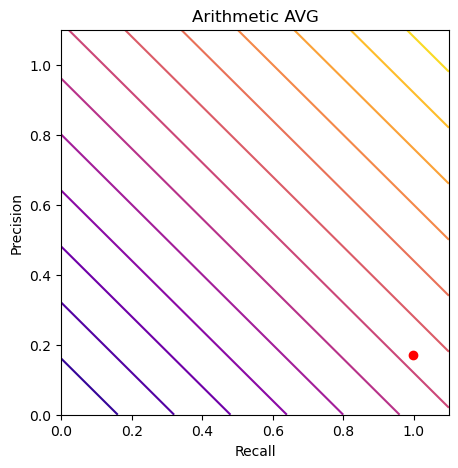

In [27]:
### Покажем на примере среднего арифметического, что должно у вас получиться

metric_func = lambda x, y: (x + y)/2

arithm_idx = (metric_func(precision, recall)).argmax()

print(f"Precision:\t {precision[arithm_idx]}")
print(f"Recall: \t {recall[arithm_idx]}")
print(f"Threshold:\t {thres[arithm_idx]}")

level_lines(metric_func, "Arithmetic AVG")
plt.plot(recall[arithm_idx], precision[arithm_idx], 'ro');

Precision:	 0.22387976621207903
Recall: 	 0.809418394043067
Threshold:	 0.1260141381736652


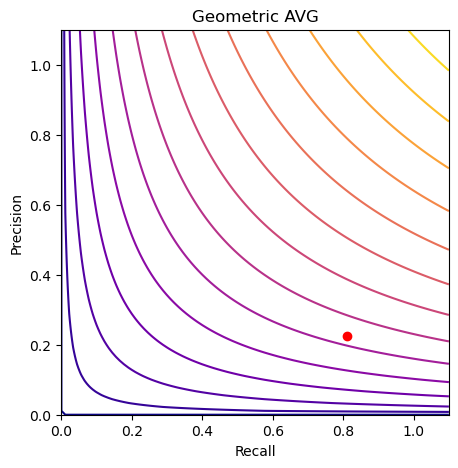

In [28]:
### Повторите для среднего геометрического
### Your code is here
metric_func = lambda x, y: (x * y)**0.5

geom_idx = (metric_func(precision, recall)).argmax()

print(f"Precision:\t {precision[geom_idx]}")
print(f"Recall: \t {recall[geom_idx]}")
print(f"Threshold:\t {thres[geom_idx]}")

level_lines(metric_func, "Geometric AVG")
plt.plot(recall[geom_idx], precision[geom_idx], 'ro');







Precision:	 0.3586650583031765
Recall: 	 0.3590259609579392
Threshold:	 0.236624895218394


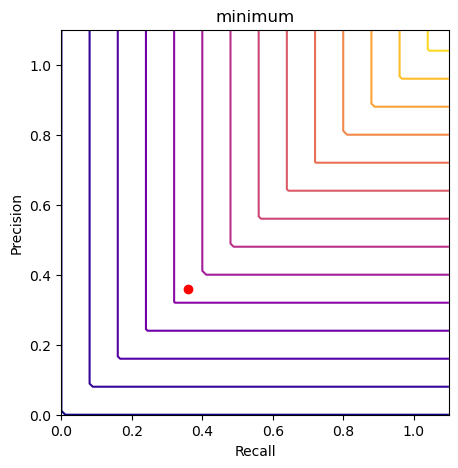

In [29]:
### Повторите для минимума
### Your code is here

metric_func = lambda x, y: np.minimum(x, y)

min_idx = (metric_func(precision, recall)).argmax()

print(f"Precision:\t {precision[min_idx]}")
print(f"Recall: \t {recall[min_idx]}")
print(f"Threshold:\t {thres[min_idx]}")

level_lines(metric_func, "minimum")
plt.plot(recall[min_idx], precision[min_idx], 'ro');







**Задание 5.** Одним из самых распространенных показателей качества является **F-мера**, которая обобщает все вышерассмотренные метрики. Более того, в ней можно регулировать параметр $\beta^2$, который отвечает за предпочтение между precision и recall. 
$$
F = \dfrac{(1 + \beta^2) P \cdot R}{\beta^2 P + R}
$$
* При $\beta^2 = 1$ и precision, и recall нам важны в равной степени.
* При $\beta^2 > 1$ предпочтение отдается recall. Похоже на решение задачи, где мы фиксируем приемлемое для нас значение precision и максимизируем recall.
* При $0 < \beta^2 < 1$ предпочтение отдается precision. Похоже на решение задачи, где мы фиксируем приемлемое для нас значение recall и максимизируем precision.

Найдите порог, который максимизирует:
1) F-меру с $\beta^2 = 1$,
2) F-меру с $\beta^2 = 0.05$,
3) F-меру с $\beta^2 = 4$.\
Для всех трех случаев выведите precision, recall, threshold и F-меру. 
Нарисуйте линии уровня и точку, которая максимизирует F-меру по аналогии с предыдущим пунктом.

Precision:	 0.285
Recall: 	 0.524
Threshold: 	 0.193
F-мера: 	 0.369
[0.193, 0.285, 0.524, 0.369]


C:\Users\olegs\AppData\Local\Temp\ipykernel_17848\4003332154.py:5: RuntimeWarning: invalid value encountered in divide
  metric_func = lambda x, y: (1+b_sq)*x*y/(b_sq * x + y)


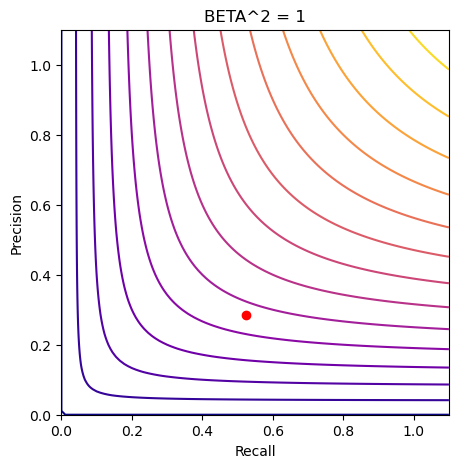

In [30]:
### Повторите для F-меры при \beta^2=1
### Выведите ее вместе с precision/recall/threshold
### Your code is here
b_sq = 1
metric_func = lambda x, y: (1+b_sq)*x*y/(b_sq * x + y)

beta_idx = (metric_func(precision, recall)).argmax()

print(f"Precision:\t {precision[beta_idx].round(3)}")
print(f"Recall: \t {recall[beta_idx].round(3)}")
print(f"Threshold: \t {thres[beta_idx].round(3)}")
print(f"F-мера: \t {((1+b_sq)*recall[beta_idx]*precision[beta_idx]/(b_sq * precision[beta_idx] + recall[beta_idx])).round(3)}")
print([thres[beta_idx].round(3), precision[beta_idx].round(3), recall[beta_idx].round(3),
      ((1+b_sq)*recall[beta_idx]*precision[beta_idx]/(b_sq * precision[beta_idx] + recall[beta_idx])).round(3)])

level_lines(metric_func, "BETA^2 = 1")
plt.plot(recall[beta_idx], precision[beta_idx], 'ro');


Precision:	 0.643
Recall: 	 0.109
Threshold:	 0.497
F-мера: 	 0.521
[0.497, 0.643, 0.109, 0.521]


C:\Users\olegs\AppData\Local\Temp\ipykernel_17848\2466235447.py:5: RuntimeWarning: invalid value encountered in divide
  metric_func = lambda x, y: (1+b_sq)*x*y/(b_sq * x + y)


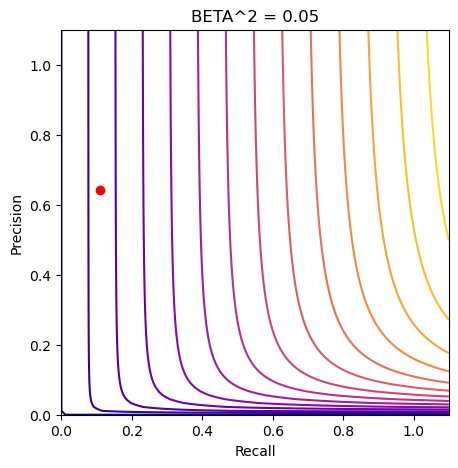

In [31]:
### Повторите для F-меры при \beta^2=0.05
### Выведите ее вместе с precision/recall/threshold
### Your code is here
b_sq = 0.05
metric_func = lambda x, y: (1+b_sq)*x*y/(b_sq * x + y)

beta_idx = (metric_func(precision, recall)).argmax()

print(f"Precision:\t {precision[beta_idx].round(3)}")
print(f"Recall: \t {recall[beta_idx].round(3)}")
print(f"Threshold:\t {thres[beta_idx].round(3)}")
print(f"F-мера: \t {((1+b_sq)*recall[beta_idx]*precision[beta_idx]/(b_sq * precision[beta_idx] + recall[beta_idx])).round(3)}")

print([thres[beta_idx].round(3), precision[beta_idx].round(3), recall[beta_idx].round(3),
      ((1+b_sq)*recall[beta_idx]*precision[beta_idx]/(b_sq * precision[beta_idx] + recall[beta_idx])).round(3)])

level_lines(metric_func, "BETA^2 = 0.05")
plt.plot(recall[beta_idx], precision[beta_idx], 'ro');

Precision:	 0.211
Recall: 	 0.86
Threshold:	 0.109
F-мера: 	 0.532
[0.109, 0.211, 0.86, 0.532]


C:\Users\olegs\AppData\Local\Temp\ipykernel_17848\328814020.py:5: RuntimeWarning: invalid value encountered in divide
  metric_func = lambda x, y: (1+b_sq)*x*y/(b_sq * x + y)


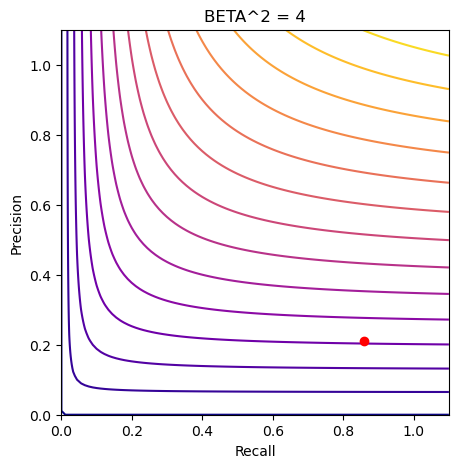

In [32]:
### Повторите для F-меры при \beta^2=4
### Выведите ее вместе с precision/recall/threshold
### Your code is here
b_sq = 4
metric_func = lambda x, y: (1+b_sq)*x*y/(b_sq * x + y)

beta_idx = (metric_func(precision, recall)).argmax()

print(f"Precision:\t {precision[beta_idx].round(3)}")
print(f"Recall: \t {recall[beta_idx].round(3)}")
print(f"Threshold:\t {thres[beta_idx].round(3)}")
print(f"F-мера: \t {((1+b_sq)*recall[beta_idx]*precision[beta_idx]/(b_sq * precision[beta_idx] + recall[beta_idx])).round(3)}")

print([thres[beta_idx].round(3), precision[beta_idx].round(3), recall[beta_idx].round(3),
      ((1+b_sq)*recall[beta_idx]*precision[beta_idx]/(b_sq * precision[beta_idx] + recall[beta_idx])).round(3)])

level_lines(metric_func, "BETA^2 = 4")
plt.plot(recall[beta_idx], precision[beta_idx], 'ro');
